In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce


import dask
import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

### Load TLGRF Benchmark Dataset

In [2]:
benchmark_TLGRF_dataset = dd.read_csv("../generate_benchmark_TLGRF_dataset/benchmark_TLGRF_dataset.csv", assume_missing=True).compute()
benchmark_TLGRF_dataset["datetime"] = pd.to_datetime(benchmark_TLGRF_dataset["datetime"])

df = benchmark_TLGRF_dataset.copy()
fips_list = df["fips"].unique()
display(benchmark_TLGRF_dataset)

,fips,county,state,days_from_start,datetime,intercept_TLGRF,r_TLGRF,log_rolled_cases,TLGRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001.0,Autauga,Alabama,87.0,2020-04-17,-26.766326,0.028066,3.082565,3.227285,3.170286
1,1001.0,Autauga,Alabama,88.0,2020-04-18,-313.778047,0.007752,3.082565,3.085088,3.205646
2,1001.0,Autauga,Alabama,89.0,2020-04-19,-60.990643,0.021119,3.095578,3.192355,3.228543
3,1001.0,Autauga,Alabama,90.0,2020-04-20,-54.020959,0.022045,3.114784,3.219041,3.256447
4,1001.0,Autauga,Alabama,91.0,2020-04-21,-216.383634,0.010171,3.114784,3.135925,3.283593
...,...,...,...,...,...,...,...,...,...,...
129892,99999.0,New York City,New York,1153.0,2023-03-19,1456.032249,-0.030986,9.544910,9.327926,NaN
129893,99999.0,New York City,New York,1154.0,2023-03-20,1389.214236,-0.039535,9.496922,9.220095,NaN
129894,99999.0,New York City,New York,1155.0,2023-03-21,1323.021840,-0.054503,9.430264,9.048656,NaN
129895,99999.0,New York City,New York,1156.0,2023-03-22,1531.624962,-0.024711,9.405575,9.232510,NaN


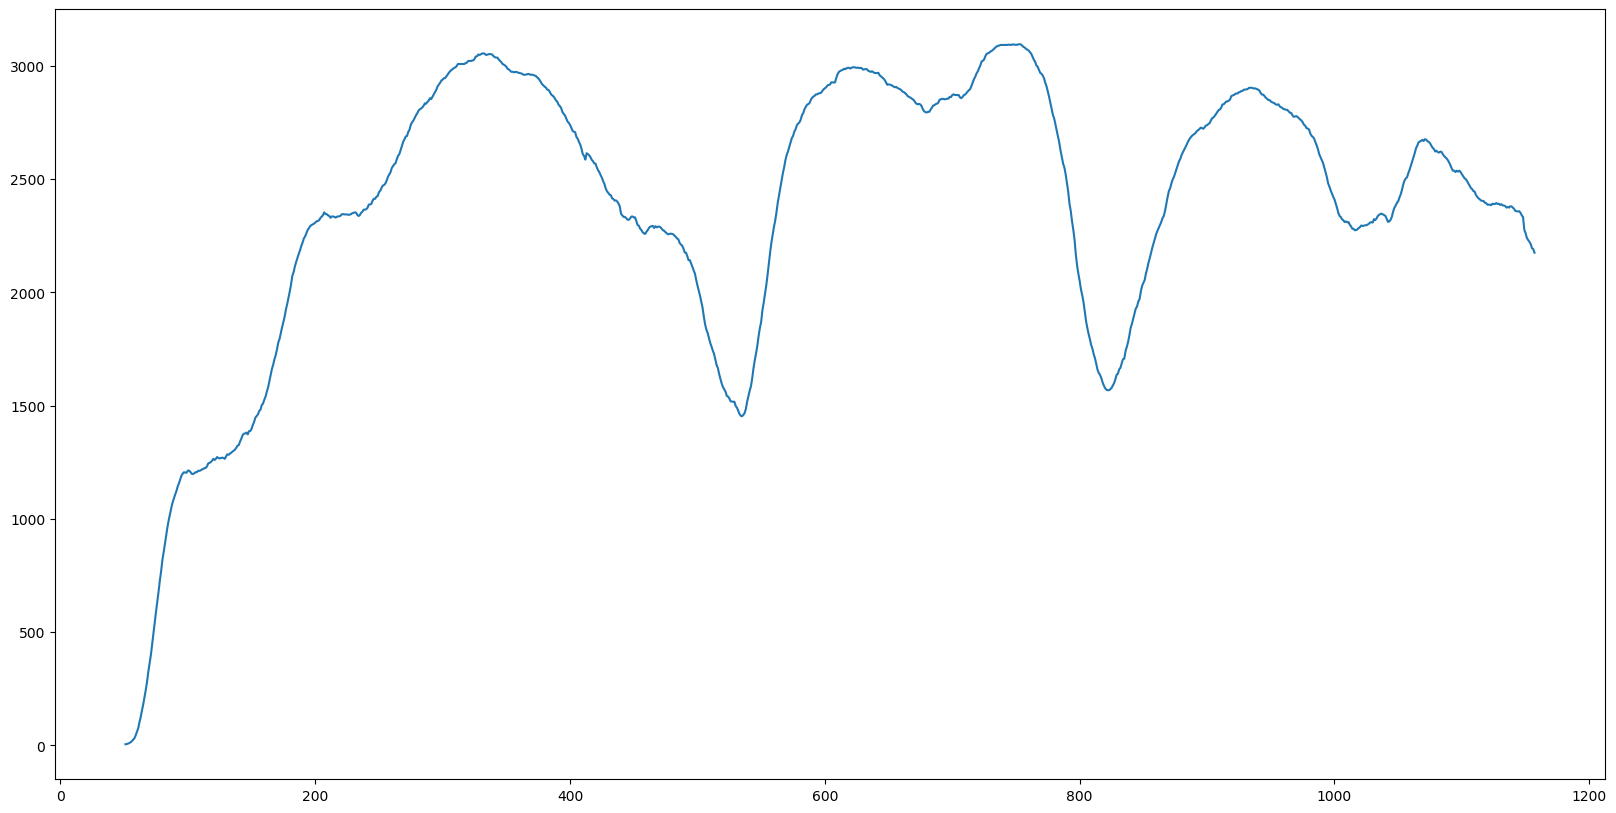

In [3]:
plt.figure(figsize=(20,10))
plt.plot(benchmark_TLGRF_dataset.groupby("days_from_start")["TLGRF_predicted_log_rolled_cases"].count())
plt.show()

### Define `read_csv_file` helper

In [4]:
def read_csv_file(file_path):
    # Read the CSV file into a pandas DataFrame
    try:
        GRF_df = pd.read_csv(file_path)
        return GRF_df
    except pd.errors.EmptyDataError:
        print(file_path)

### Read Time Variant GRF

In [5]:
directory = "./time_variant_grf_results/time_variant_grf_backtest_state_forests_windowsize=2_numtrees=100"
time_variant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(time_variant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    time_variant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in time_variant_file_paths)
    pbar.update(len(time_variant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()


In [6]:
time_variant_GRF_results = pd.concat(time_variant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
time_variant_GRF_results["date"] = pd.to_datetime(time_variant_GRF_results["date"])
time_variant_GRF_results = time_variant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
time_variant_GRF_results = time_variant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])
time_variant_GRF_results["shifted_log_rolled_cases"] = time_variant_GRF_results.groupby("fips")["log_rolled_cases"].shift(-7)
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(time_variant_GRF_results)

,fips,date,county,state,days_from_start,rolled_cases,log_rolled_cases,shifted_days_from_start,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,20.285714,3.062723,0,0.029451,3.268881,3.133629
0,1001,2020-04-17,Autauga,Alabama,87,20.714286,3.082565,1,0.033634,3.318004,3.170286
0,1001,2020-04-18,Autauga,Alabama,88,20.714286,3.082565,2,0.028902,3.284877,3.205646
0,1001,2020-04-19,Autauga,Alabama,89,21.000000,3.095578,3,0.025175,3.271800,3.228543
0,1001,2020-04-20,Autauga,Alabama,90,21.428571,3.114784,4,0.023614,3.280084,3.256447
...,...,...,...,...,...,...,...,...,...,...,...
2229,99999,2023-03-19,New York City,New York,1153,13972.285714,9.544910,1103,-0.009829,9.476110,NaN
2220,99999,2023-03-20,New York City,New York,1154,13317.571429,9.496922,1104,-0.004860,9.462904,NaN
2204,99999,2023-03-21,New York City,New York,1155,12458.714286,9.430264,1105,-0.002493,9.412810,NaN
2193,99999,2023-03-22,New York City,New York,1156,12154.857143,9.405575,1106,-0.003673,9.379860,NaN


In [7]:
time_varying_counts = time_variant_GRF_results.groupby("date")["GRF_predicted_log_rolled_cases"].count()
display(time_varying_counts.sort_values())
time_variant_GRF_results[time_variant_GRF_results["date"]=="2021-08-07"]

date
2020-03-09       3
2020-03-10       4
2020-03-11       5
2020-03-12       6
2020-03-13       8
              ... 
2022-02-07    3095
2022-02-12    3096
2022-02-11    3096
2022-02-06    3096
2022-02-10    3097
Name: GRF_predicted_log_rolled_cases, Length: 1110, dtype: int64

,fips,date,county,state,days_from_start,rolled_cases,log_rolled_cases,shifted_days_from_start,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2021-08-07,Autauga,Alabama,564,329.571429,5.801125,478,0.000328,5.803423,6.185532
1,1003,2021-08-07,Baldwin,Alabama,564,3789.000000,8.240148,490,-0.000228,8.238554,8.503404
2,1005,2021-08-07,Barbour,Alabama,564,180.857143,5.203771,472,0.001381,5.213441,5.600906
3,1007,2021-08-07,Bibb,Alabama,564,235.571429,5.466673,476,0.002158,5.481778,5.722043
4,1009,2021-08-07,Blount,Alabama,564,421.000000,6.045242,470,0.000142,6.046239,6.306718
...,...,...,...,...,...,...,...,...,...,...,...
2457,56041,2021-08-07,Uinta,Wyoming,564,130.571429,4.880310,422,0.001707,4.892257,5.285160
2458,56045,2021-08-07,Weston,Wyoming,564,25.142857,3.267394,304,0.000678,3.272137,3.520883
2459,78010,2021-08-07,St. Croix,Virgin Islands,564,235.000000,5.464255,398,0.000921,5.470705,5.710758
2460,78030,2021-08-07,St. Thomas,Virgin Islands,564,425.428571,6.055679,482,0.000980,6.062537,6.329390


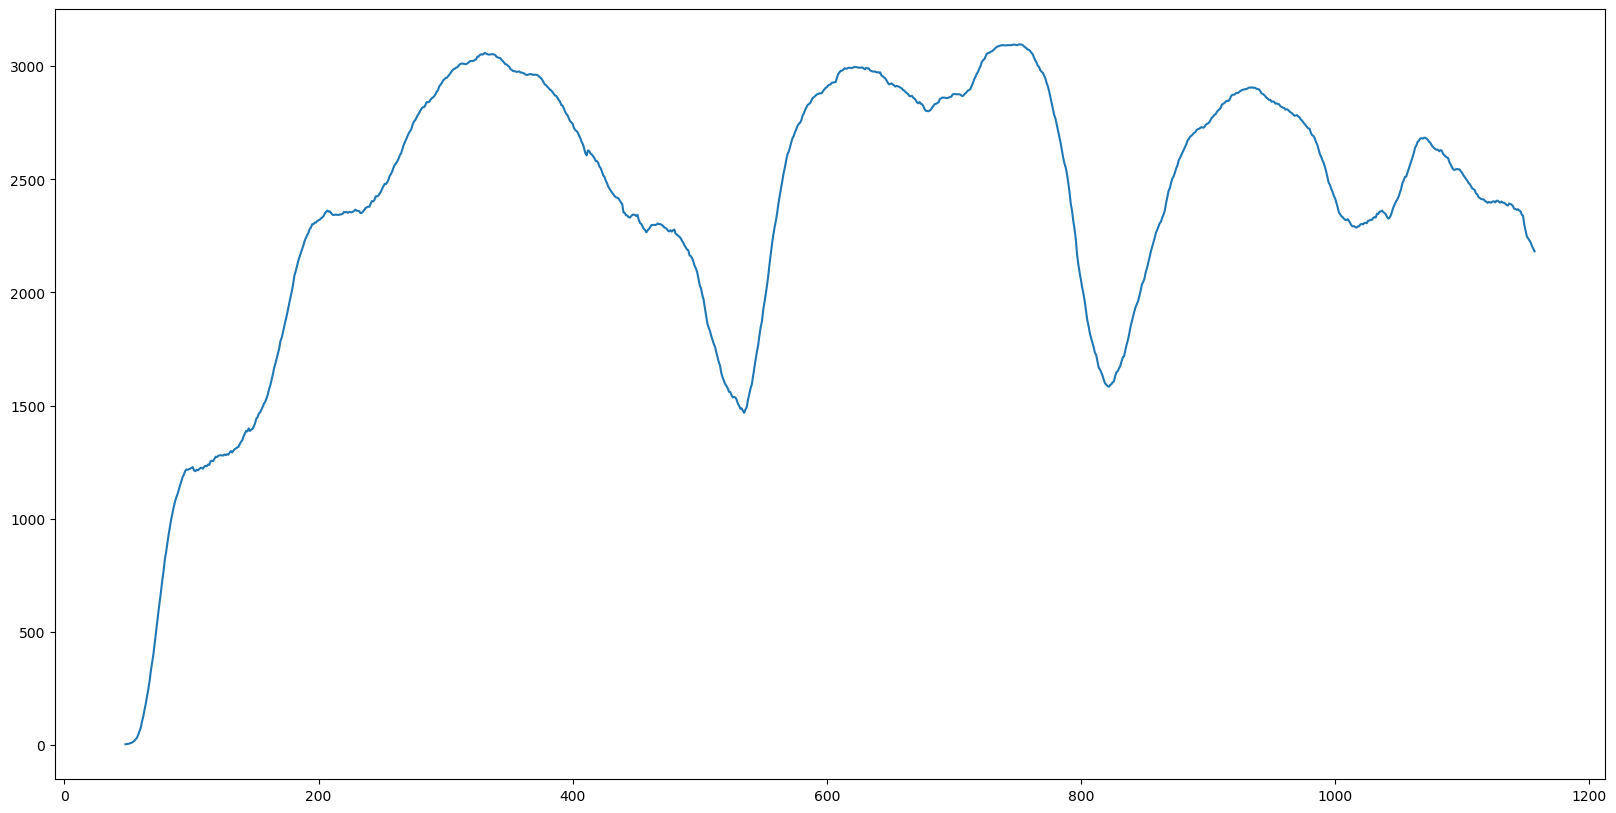

In [8]:
plt.figure(figsize=(20,10))
plt.plot(time_variant_GRF_results.groupby("days_from_start")["GRF_predicted_log_rolled_cases"].count())
plt.show()

### Read Time Invariant GRF

In [9]:
directory = "./time_invariant_grf_results/time_invariant_grf_backtest_state_forests_windowsize=2_numtrees=100"
time_invariant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(time_invariant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    time_invariant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in time_invariant_file_paths)
    pbar.update(len(time_invariant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()


In [10]:
time_invariant_GRF_results = pd.concat(time_invariant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
time_invariant_GRF_results["date"] = pd.to_datetime(time_invariant_GRF_results["date"])
time_invariant_GRF_results = time_invariant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
time_invariant_GRF_results = time_invariant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])

time_invariant_GRF_results["shifted_log_rolled_cases"] = time_invariant_GRF_results.groupby("fips")["log_rolled_cases"].shift(-7)
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(time_invariant_GRF_results)

,fips,date,county,state,days_from_start,log_rolled_cases,shifted_days_from_start,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,3.062723,0,0.088425,3.681699,3.133629
0,1001,2020-04-17,Autauga,Alabama,87,3.082565,1,0.081830,3.655375,3.170286
0,1001,2020-04-18,Autauga,Alabama,88,3.082565,2,0.083574,3.667585,3.205646
0,1001,2020-04-19,Autauga,Alabama,89,3.095578,3,0.075670,3.625265,3.228543
0,1001,2020-04-20,Autauga,Alabama,90,3.114784,4,0.069887,3.603995,3.256447
...,...,...,...,...,...,...,...,...,...,...
2229,99999,2023-03-19,New York City,New York,1153,9.544910,1103,0.001397,9.554692,NaN
2220,99999,2023-03-20,New York City,New York,1154,9.496922,1104,0.001370,9.506510,NaN
2204,99999,2023-03-21,New York City,New York,1155,9.430264,1105,0.001407,9.440112,NaN
2193,99999,2023-03-22,New York City,New York,1156,9.405575,1106,0.001395,9.415341,NaN


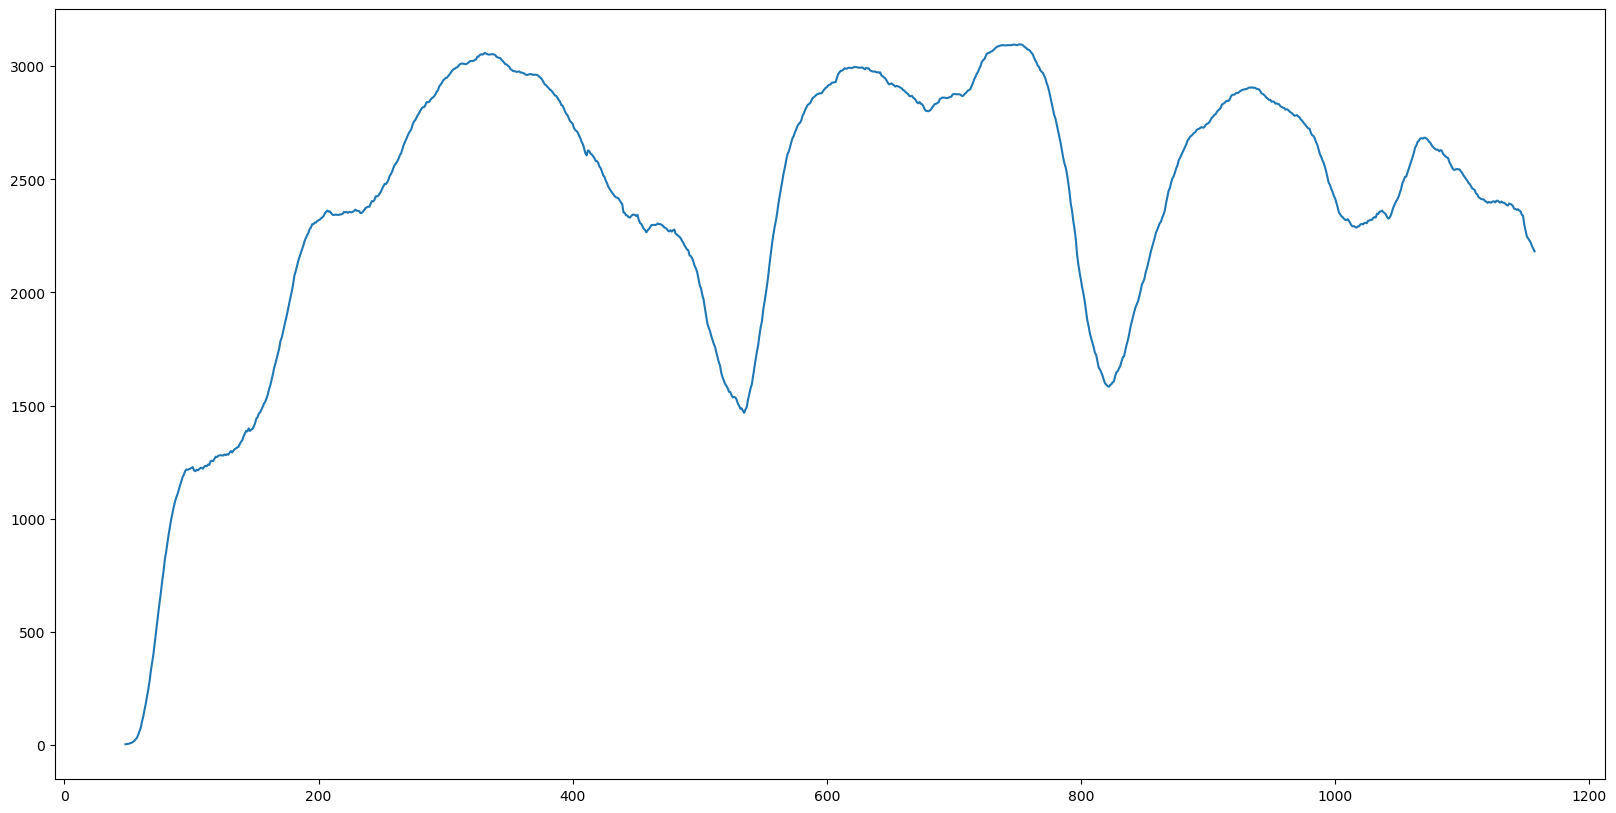

In [11]:
plt.figure(figsize=(20,10))
plt.plot(time_invariant_GRF_results.groupby("days_from_start")["GRF_predicted_log_rolled_cases"].count())
plt.show()

### Compute RMSE and MAE

In [12]:
rmse_GRF_func = lambda x: np.sqrt(np.nanmean((x["GRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_GRF_func = lambda x: np.nanmean(np.abs(x["GRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))
rmse_TLGRF_func = lambda x: np.sqrt(np.nanmean((x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_TLGRF_func = lambda x: np.nanmean(np.abs(x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))
#

log_20 = np.log(20)

TLGRF_df = benchmark_TLGRF_dataset[benchmark_TLGRF_dataset["log_rolled_cases"] >= log_20]
TLGRF_df = TLGRF_df[TLGRF_df["datetime"] <= "2022-12-31"]


time_invariant_GRF_df = time_invariant_GRF_results[time_invariant_GRF_results["log_rolled_cases"] >= log_20]
time_invariant_GRF_df = time_invariant_GRF_df[time_invariant_GRF_df["date"] <= "2022-12-31"]

time_variant_GRF_df = time_variant_GRF_results[time_variant_GRF_results["log_rolled_cases"] >= log_20]
time_variant_GRF_df = time_variant_GRF_df[time_variant_GRF_df["date"] <= "2022-12-31"]


#TLGRF
RMSE_TLGRF = TLGRF_df.groupby("datetime").apply(rmse_TLGRF_func)
MAE_TLGRF = TLGRF_df.groupby("datetime").apply(mae_TLGRF_func)
#Time Invariant GRF
RMSE_time_invariant_GRF_df = time_invariant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_time_invariant_GRF_df = time_invariant_GRF_df.groupby("date").apply(mae_GRF_func)
#Time Variant GRF
RMSE_time_variant_GRF_df = time_variant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_time_variant_GRF_df = time_variant_GRF_df.groupby("date").apply(mae_GRF_func)


In [13]:
metrics_comparison_df = pd.DataFrame()

metrics_comparison_df["RMSE"] = [RMSE_time_invariant_GRF_df.median(), RMSE_time_variant_GRF_df.median(), RMSE_TLGRF.median()]
metrics_comparison_df["MAE"] = [MAE_time_invariant_GRF_df.median(), MAE_time_variant_GRF_df.median(), MAE_TLGRF.median()]
metrics_comparison_df.index = ["Time Invariant GRF", "Time Variant GRF", "TLGRF"]
metrics_comparison_df

,RMSE,MAE
Time Invariant GRF,0.280389,0.212555
Time Variant GRF,0.265692,0.200136
TLGRF,0.210543,0.132172


In [14]:
[RMSE_time_invariant_GRF_df.median(), RMSE_TLGRF.median()]

[0.28038903772967894, 0.21054261936946783]

In [15]:
[MAE_time_invariant_GRF_df.median(), MAE_TLGRF.median()]

[0.21255463241253103, 0.1321716471463828]

In [16]:
days_to_date_df = time_variant_GRF_results[["days_from_start","date"]]
days_to_date_df.drop_duplicates(inplace=True)
days_to_date_df = days_to_date_df.sort_values(by="date")

date0 = days_to_date_df["date"].min() - pd.Timedelta(days=days_to_date_df["days_from_start"].min())
date0 = date0.date()
missing_days_df = pd.DataFrame({'days_from_start': range(0, days_to_date_df["days_from_start"].max()),
                                'date': pd.date_range(start=date0, periods=days_to_date_df["days_from_start"].max())})
#date0, days_to_date_df["date"].min(), pd.Timedelta(days=days_to_date_df["days_from_start"].min())
missing_days_df

/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


,days_from_start,date
0,0,2020-01-21
1,1,2020-01-22
2,2,2020-01-23
3,3,2020-01-24
4,4,2020-01-25
...,...,...
1152,1152,2023-03-18
1153,1153,2023-03-19
1154,1154,2023-03-20
1155,1155,2023-03-21


In [46]:
days_to_date_df[days_to_date_df["date"]=="2021-09-12"]

,days_from_start,date
0,600,2021-09-12


### Load Other Benchmarks

In [18]:
with open("../benchmark_tcv_kmeans_code/first_design_merged_df_dict.pickle", 'rb') as file:
    first_design_merged_df_dict = pickle.load(file)
with open("../benchmark_tcv_kmeans_code/second_design_merged_df_dict.pickle", 'rb') as file:
    second_design_merged_df_dict = pickle.load(file)


In [19]:
ctcv_df = second_design_merged_df_dict[3136]
tcv_df = second_design_merged_df_dict[1]
ctcv_df = pd.merge(ctcv_df, days_to_date_df, on="days_from_start", how="left")
tcv_df = pd.merge(tcv_df, days_to_date_df, on="days_from_start", how="left")
ctcv_df

,days_from_start,total_mse,total_mae,nsamples_mse,nsamples_mae,rmse,mae,date
0,20.0,0.559616,0.313170,1.0,1.0,0.748075,0.313170,NaT
1,21.0,0.693147,0.480453,1.0,1.0,0.832555,0.480453,NaT
2,22.0,0.372013,0.138393,1.0,1.0,0.609928,0.138393,NaT
3,23.0,0.722027,0.261866,2.0,2.0,0.600844,0.130933,NaT
4,24.0,1.338507,0.632752,3.0,3.0,0.667959,0.210917,NaT
...,...,...,...,...,...,...,...,...
1124,1144.0,934.131399,1927.583972,3136.0,3136.0,0.545778,0.614663,2023-03-10
1125,1145.0,969.227173,2169.818787,3136.0,3136.0,0.555936,0.691907,2023-03-11
1126,1146.0,1076.336616,2492.645367,3136.0,3136.0,0.585849,0.794849,2023-03-12
1127,1147.0,1190.343785,2615.273718,3136.0,3136.0,0.616096,0.833952,2023-03-13


In [20]:
tcv_df

,days_from_start,total_mse,total_mae,nsamples_mse,nsamples_mae,rmse,mae,date
0,20.0,0.241162,0.058159,8.0,8.0,0.173624,0.007270,NaT
1,21.0,0.336472,0.113214,9.0,9.0,0.193354,0.012579,NaT
2,22.0,0.441833,0.195216,9.0,9.0,0.221568,0.021691,NaT
3,23.0,0.559616,0.313170,9.0,9.0,0.249358,0.034797,NaT
4,24.0,0.693147,0.480453,9.0,9.0,0.277518,0.053384,NaT
...,...,...,...,...,...,...,...,...
1042,1062.0,662.085962,512.866665,3136.0,3136.0,0.459483,0.163542,2022-12-18
1043,1063.0,712.640695,587.808026,3136.0,3136.0,0.476702,0.187439,2022-12-19
1044,1064.0,790.143238,629.956877,3136.0,3136.0,0.501955,0.200879,2022-12-20
1045,1065.0,805.520276,543.439982,3136.0,3136.0,0.506816,0.173291,2022-12-21


In [21]:
tcv_df["days_from_start"].value_counts().sort_values()

20.0      1
51.0      1
22.0      1
23.0      1
24.0      1
         ..
1061.0    1
1062.0    1
1063.0    1
1065.0    1
1066.0    1
Name: days_from_start, Length: 1047, dtype: int64

In [22]:
tcv_performance_df = tcv_df[["date","rmse","mae"]]
tcv_performance_df = tcv_performance_df.sort_values(by="date")
tcv_performance_df = tcv_performance_df[tcv_performance_df["date"].isin(MAE_time_variant_GRF_df.index)]
tcv_performance_df.set_index("date", inplace=True)


ctcv_performance_df = ctcv_df[["date","rmse","mae"]]
ctcv_performance_df = ctcv_performance_df.sort_values(by="date")
ctcv_performance_df = ctcv_performance_df[ctcv_performance_df["date"].isin(MAE_time_variant_GRF_df.index)]
ctcv_performance_df.set_index("date", inplace=True)

In [34]:
metrics_comparison_df

,RMSE,MAE
Time Invariant GRF,0.280389,0.212555
Time Variant GRF,0.265692,0.200136
TLGRF,0.210543,0.132172


In [35]:
ctcv_performance_df["rmse"].median(), ctcv_performance_df["mae"].median() 

(0.4355455227598498, 0.14600482146524474)

In [36]:
tcv_performance_df["rmse"].median(), tcv_performance_df["mae"].median()

(0.518363391805105, 0.2003732428283616)

### Plot TLGRF vs GRF

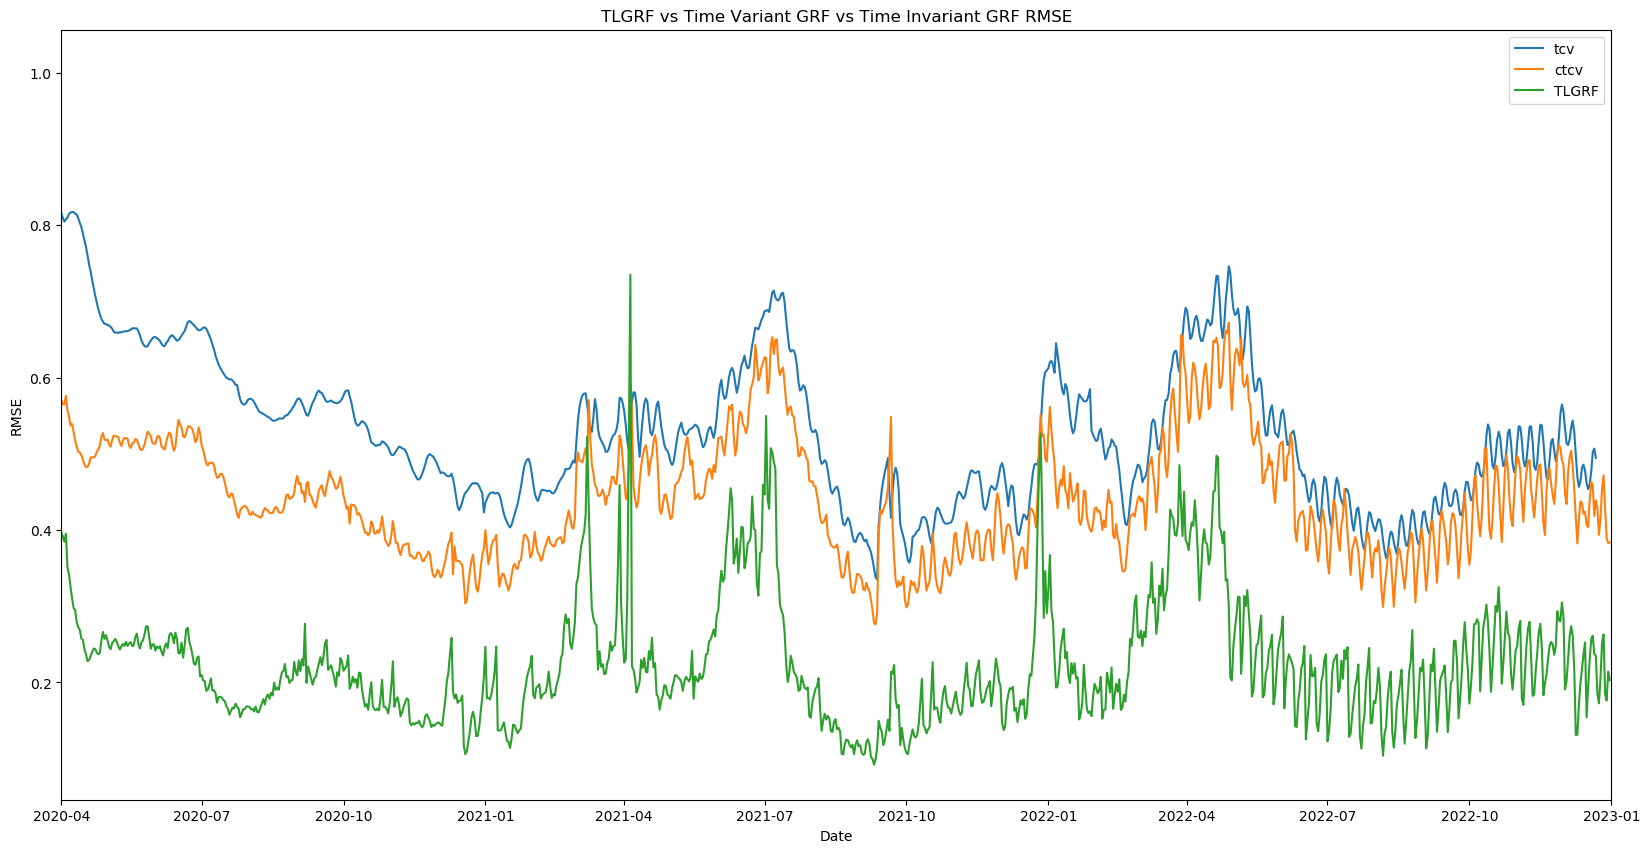

In [43]:
plt.figure(figsize=(20,10))

plt.plot(tcv_performance_df["rmse"], label="tcv")
plt.plot(ctcv_performance_df["rmse"], label="ctcv")
#plt.plot(RMSE_time_invariant_GRF_df, label="Time Invariant GRF")
#plt.plot(RMSE_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(RMSE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("TLGRF vs Time Variant GRF vs Time Invariant GRF RMSE")
plt.xlim(pd.to_datetime('2020-04-01'), pd.to_datetime('2023-01-01'))
plt.show()

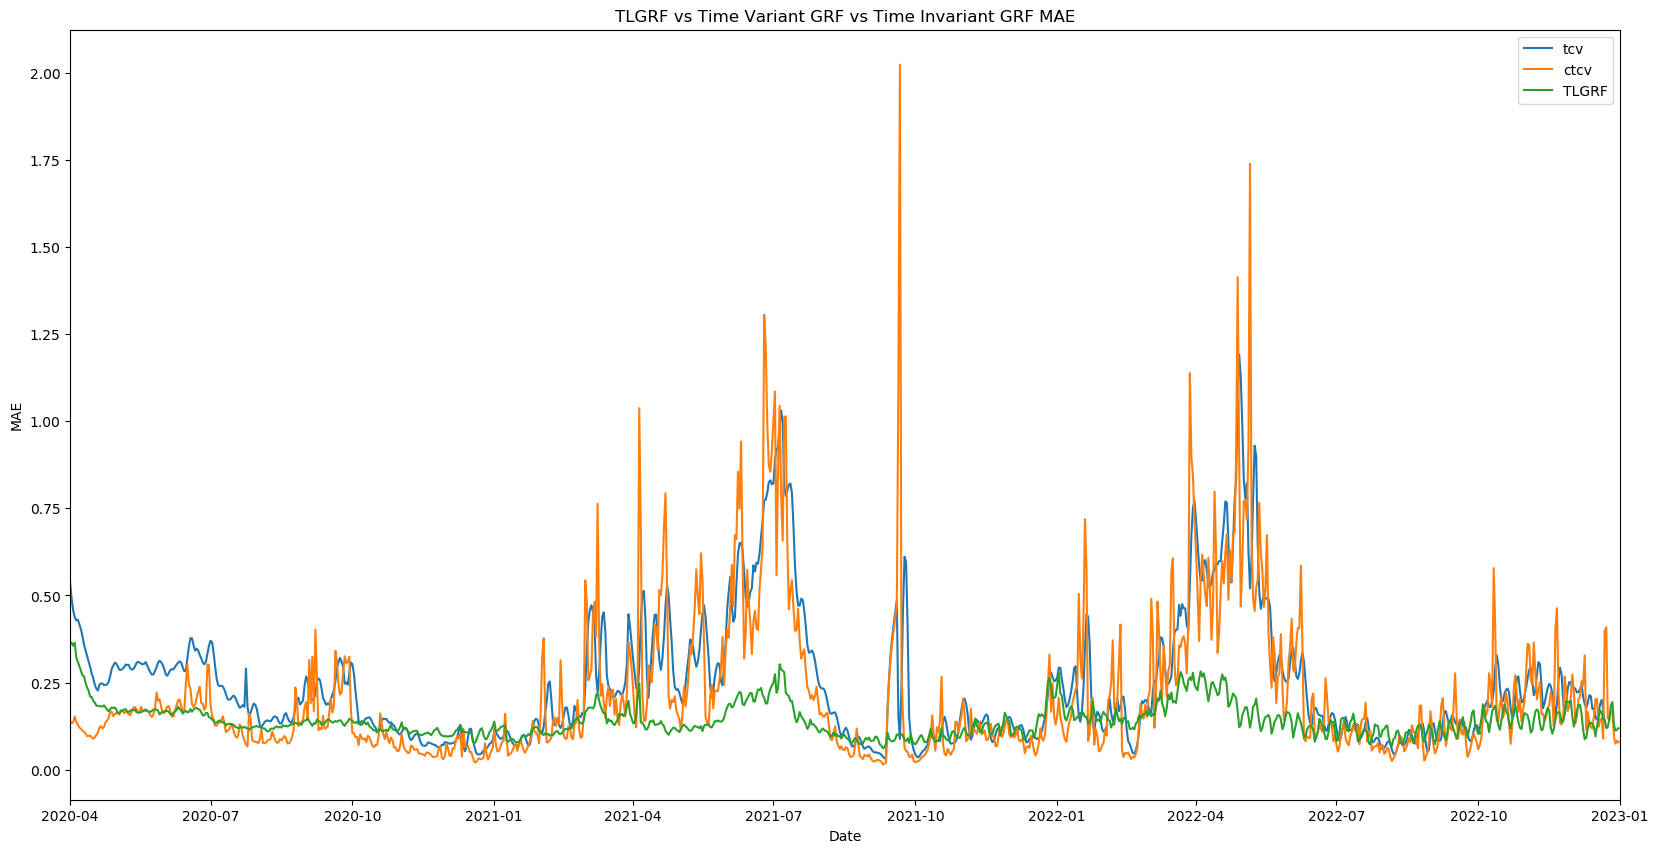

In [44]:
plt.figure(figsize=(20,10))

plt.plot(tcv_performance_df["mae"], label="tcv")
plt.plot(ctcv_performance_df["mae"], label="ctcv")
#plt.plot(MAE_time_invariant_GRF_df, label="Time Invariant GRF")
#plt.plot(MAE_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(MAE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("TLGRF vs Time Variant GRF vs Time Invariant GRF MAE")
plt.xlim(pd.to_datetime('2020-04-01'), pd.to_datetime('2023-01-01'))

plt.show()

In [27]:
log_20 = np.log(20)
(TLGRF_df["log_rolled_cases"] <= log_20).sum()

0

In [28]:
RMSE_time_variant_GRF_df[~RMSE_time_variant_GRF_df.isna()].sort_values().tail(20)

date
2022-01-04    0.566061
2022-02-20    0.566526
2020-03-25    0.567353
2020-03-27    0.568743
2022-01-03    0.569378
2020-03-22    0.591109
2020-03-23    0.617010
2020-03-26    0.619091
2020-03-21    0.632679
2020-03-18    0.640525
2020-03-10    0.660122
2020-03-19    0.689595
2020-03-17    0.708298
2020-03-13    0.708411
2020-03-11    0.718934
2020-03-12    0.735298
2020-03-14    0.739886
2020-03-09    0.764690
2020-03-15    0.795114
2020-03-16    0.799683
dtype: float64

In [29]:
MAE_time_variant_GRF_df[~MAE_time_variant_GRF_df.isna()].sort_values().tail(20)

date
2022-02-24    0.512254
2022-02-17    0.514462
2022-02-23    0.515969
2020-03-26    0.519980
2020-03-21    0.520181
2022-02-22    0.520339
2022-02-18    0.522048
2022-02-21    0.526672
2022-02-19    0.530319
2022-02-20    0.531159
2020-03-19    0.546887
2020-03-17    0.572086
2020-03-13    0.576314
2020-03-11    0.605819
2020-03-10    0.632006
2020-03-14    0.642082
2020-03-12    0.661500
2020-03-16    0.678276
2020-03-15    0.679244
2020-03-09    0.725362
dtype: float64

In [30]:
time_variant_GRF_df[time_variant_GRF_df["date"] == "2022-02-20"]

,fips,date,county,state,days_from_start,rolled_cases,log_rolled_cases,shifted_days_from_start,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2022-02-20,Autauga,Alabama,761,1993.000000,7.597948,675,-0.000732,7.592826,6.499293
1,1003,2022-02-20,Baldwin,Alabama,761,4096.714286,8.318209,687,-0.000980,8.311350,7.510485
2,1005,2022-02-20,Barbour,Alabama,761,345.571429,5.848377,669,-0.000670,5.843687,4.962545
3,1007,2022-02-20,Bibb,Alabama,761,511.428571,6.239356,673,-0.000095,6.238691,5.379700
4,1009,2022-02-20,Blount,Alabama,761,1130.857143,7.031703,667,-0.000400,7.028902,6.338266
...,...,...,...,...,...,...,...,...,...,...,...
3055,69110,2022-02-20,Saipan,Northern Mariana Islands,761,1100.000000,7.004065,580,0.000086,7.004666,5.753796
3056,78010,2022-02-20,St. Croix,Virgin Islands,761,414.000000,6.028519,595,0.000003,6.028541,5.563809
3057,78020,2022-02-20,St. John,Virgin Islands,761,29.857143,3.432604,529,0.000102,3.433314,3.158215
3058,78030,2022-02-20,St. Thomas,Virgin Islands,761,211.000000,5.357058,679,0.000028,5.357256,4.826827
